# HeuGNetTriplet — Explainability for Research Paper

Generates publication-quality figures using three complementary XAI methods:

| Method | What it explains | How |
|--------|-----------------|-----|
| **GNNExplainer** | Which nodes and edges the model most relies on | Learns a soft mask that maximises mutual information between masked subgraph and prediction |
| **Integrated Gradients** (SHAP-style) | Which atomic *features* drive the prediction, resolved per atom | Accumulates gradients along a straight path from a zero baseline to the input |
| **Grad-CAM** | Which atoms are most activated in the final interaction layer | Weights the last-block node embeddings by the gradient of the prediction w.r.t. those embeddings |
| **Attention weights** | Which atoms the pooling layer focuses on | Gate scores from `AttentionalAggregation` — free interpretability from the model itself |

**Figures produced:**
- `fig1_node_importance_panel.pdf` — per-atom importance, all 4 methods, one example structure
- `fig2_crystal_structure_gradcam.pdf` — 3-D crystal coloured by Grad-CAM importance
- `fig3_edge_importance.pdf` — top-K edges from GNNExplainer
- `fig4_method_agreement.pdf` — Spearman correlation across methods
- `fig5_element_importance.pdf` — element-level importance aggregated over the test set
- `fig6_attention_vs_distance.pdf` — attention score vs bond length (physics check)

**Prerequisites:** `HeuGNet_best.pth`, `graphs.pt` in the working directory.

In [ ]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────
!pip install torch_geometric captum -q
!pip install pymatgen -q
# Note: graphshap has brittle dependencies; we use captum IntegratedGradients
# which is the standard, numerically reliable SHAP-equivalent for GNNs.

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.

In [ ]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────
import random, math, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.stats import spearmanr
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, AttentionalAggregation
from torch_geometric.explain import Explainer, GNNExplainer

from captum.attr import IntegratedGradients

warnings.filterwarnings('ignore')

# ── Publication style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'serif',
    'font.size'         : 11,
    'axes.labelsize'    : 12,
    'axes.titlesize'    : 13,
    'legend.fontsize'   : 10,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'figure.dpi'        : 150,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
PALETTE = ['#2166ac', '#d6604d', '#4dac26', '#7b3294']  # colourblind-safe

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:
# ── Cell 3: Reproduce model architecture (identical to training notebook) ─
#
# Every class below is copied verbatim from Phy_In_HeuGNet_Optimized.ipynb.
# Do NOT modify — the state_dict keys must match exactly for checkpoint loading.

# ── 3a: Atomic descriptor table ──────────────────────────────────────────
ATOMIC_EXTRA = {
     3: (1,   6.941,  0.618,  5.392,  0),
     4: (2,   9.012,  0.000,  9.323,  0),
    11: (1,  22.990,  0.548,  5.139,  0),
    12: (2,  24.305,  0.000,  7.646,  0),
    13: (3,  26.982,  0.441,  5.986,  1),
    14: (4,  28.086,  1.385,  8.152,  1),
    19: (1,  39.098,  0.501,  4.341,  0),
    20: (2,  40.078,  0.018,  6.113,  0),
    21: (3,  44.956,  0.188,  6.561,  2),
    22: (4,  47.867,  0.079,  6.828,  2),
    23: (5,  50.942,  0.526,  6.746,  2),
    24: (6,  51.996,  0.666,  6.767,  2),
    25: (7,  54.938,  0.000,  7.434,  2),
    26: (8,  55.845,  0.163,  7.902,  2),
    27: (9,  58.933,  0.661,  7.881,  2),
    28: (10, 58.693,  1.156,  7.640,  2),
    29: (11, 63.546,  1.235,  7.727,  2),
    30: (12, 65.38,   0.000,  9.394,  2),
    31: (3,  69.723,  0.300,  5.999,  1),
    32: (4,  72.630,  1.233,  7.900,  1),
    33: (5,  74.922,  0.810,  9.815,  1),
    37: (1,  85.468,  0.486,  4.177,  0),
    38: (2,  87.620,  0.048,  5.695,  0),
    39: (3,  88.906,  0.307,  6.217,  2),
    40: (4,  91.224,  0.426,  6.634,  2),
    41: (5,  92.906,  0.893,  6.759,  2),
    42: (6,  95.960,  0.748,  7.092,  2),
    43: (7,  98.000,  0.550,  7.280,  2),
    44: (8, 101.070,  1.050,  7.361,  2),
    45: (9, 102.906,  1.137,  7.459,  2),
    46: (10,106.420,  0.562,  8.337,  2),
    47: (11,107.868,  1.302,  7.576,  2),
    48: (12,112.411,  0.000,  8.994,  2),
    49: (3, 114.818,  0.300,  5.786,  1),
    50: (4, 118.710,  1.112,  7.344,  1),
    51: (5, 121.760,  1.047,  8.608,  1),
    55: (1, 132.905,  0.472,  3.894,  0),
    56: (2, 137.327,  0.145,  5.212,  0),
    57: (3, 138.905,  0.470,  5.577,  2),
    72: (4, 178.490,  0.000,  6.825,  2),
    73: (5, 180.948,  0.322,  7.549,  2),
    74: (6, 183.840,  0.815,  7.864,  2),
    75: (7, 186.207,  0.150,  7.833,  2),
    76: (8, 190.230,  1.100,  8.438,  2),
    77: (9, 192.217,  1.565,  8.967,  2),
    78: (10,195.084,  2.128,  8.959,  2),
    79: (11,196.967,  2.309,  9.226,  2),
    80: (12,200.592,  0.000, 10.438,  2),
    81: (3, 204.383,  0.200,  6.108,  1),
    82: (4, 207.200,  0.364,  7.417,  1),
    83: (5, 208.980,  0.946,  7.289,  1),
}
_max_Z = 100
_extra = torch.zeros(_max_Z, 5)
for z, vals in ATOMIC_EXTRA.items():
    if z < _max_Z:
        _extra[z] = torch.tensor(vals, dtype=torch.float)
_mask         = _extra.abs().sum(1) > 0
_mean         = _extra[_mask].mean(0, keepdim=True)
_std          = _extra[_mask].std(0,  keepdim=True).clamp(min=1e-6)
EXTRA_TABLE   = (_extra - _mean) / _std

# ── 3b: Data class ────────────────────────────────────────────────────────
class HeuGNetData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        if key == 'triplets':
            return self.num_nodes
        return super().__inc__(key, value, *args, **kwargs)

# ── 3c: Embeddings ────────────────────────────────────────────────────────
class EdgeEmbedding(nn.Module):
    def __init__(self, num_radial=16):
        super().__init__()
        self.centers = nn.Parameter(torch.linspace(0, 5, num_radial), requires_grad=False)
        self.gamma   = 10.0
    def forward(self, distances):
        if distances.numel() == 0:
            return torch.zeros((0, self.centers.shape[0]), device=distances.device)
        d = distances.view(-1, 1)
        c = self.centers.view(1, -1)
        return torch.exp(-self.gamma * (d - c) ** 2)

class AngleEmbedding(nn.Module):
    def __init__(self, num_spherical=8):
        super().__init__()
        self.num_spherical = num_spherical
        self.out_dim = 2 * num_spherical
    def forward(self, angles):
        cos_t = [torch.cos(k * angles) for k in range(1, self.num_spherical + 1)]
        sin_t = [torch.sin(k * angles) for k in range(1, self.num_spherical + 1)]
        return torch.cat(cos_t + sin_t, dim=1)

# ── 3d: Triplet interaction block ─────────────────────────────────────────
class TripletInteractionBlock(nn.Module):
    def __init__(self, hidden_dim, edge_dim=16, angle_dim=16):
        super().__init__()
        self.edge_mlp  = nn.Sequential(nn.Linear(edge_dim,   hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.angle_mlp = nn.Sequential(nn.Linear(angle_dim,  hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.node_proj = nn.Linear(hidden_dim, hidden_dim)
        self.combine   = nn.Sequential(nn.Linear(hidden_dim * 3, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.gate      = nn.Linear(hidden_dim, hidden_dim)
        self.norm      = nn.LayerNorm(hidden_dim)

    def forward(self, x, edge_index, edge_attr_emb, triplets, angles, angle_emb):
        num_nodes = x.size(0)
        if triplets.size(0) == 0:
            return self.norm(x)
        valid = (triplets[:, 0] < num_nodes) & (triplets[:, 1] < num_nodes) & (triplets[:, 2] < num_nodes)
        triplets, angles = triplets[valid], angles[valid]
        if triplets.size(0) == 0:
            return self.norm(x)
        src, dst  = edge_index
        stride    = num_nodes + 1
        edge_keys = src * stride + dst
        i_t, j_t, k_t = triplets[:, 0], triplets[:, 1], triplets[:, 2]
        sorted_keys, sorted_idx = torch.sort(edge_keys)
        def lookup(q):
            pos   = torch.searchsorted(sorted_keys, q)
            pos_c = pos.clamp(0, sorted_keys.size(0) - 1)
            found = sorted_keys[pos_c] == q
            return sorted_idx[pos_c], found
        ij_idx, ij_ok = lookup(i_t * stride + j_t)
        jk_idx, jk_ok = lookup(j_t * stride + k_t)
        both = ij_ok & jk_ok
        if both.sum() == 0:
            return self.norm(x)
        triplets, angles = triplets[both], angles[both]
        ij_idx, jk_idx  = ij_idx[both],   jk_idx[both]
        j_t = triplets[:, 1]
        edge_feat  = self.edge_mlp(edge_attr_emb[ij_idx] + edge_attr_emb[jk_idx])
        angle_feat = self.angle_mlp(angle_emb(angles))
        node_feat  = self.node_proj(x[j_t])
        message    = self.combine(torch.cat([edge_feat, angle_feat, node_feat], dim=-1))
        agg        = torch.zeros_like(x)
        agg.index_add_(0, j_t, message)
        return self.norm(x + torch.sigmoid(self.gate(agg)) * agg)

# ── 3e: Full model ────────────────────────────────────────────────────────
class HeuGNetTriplet(nn.Module):
    def __init__(self, node_dim=6, hidden_dim=128, emb_dim=64, num_blocks=3,
                 num_radial=16, num_spherical=8, target_mean=0.0, target_std=1.0):
        super().__init__()
        self.register_buffer('target_mean', torch.tensor(target_mean))
        self.register_buffer('target_std',  torch.tensor(target_std))
        self.register_buffer('extra_table', EXTRA_TABLE.clone())
        self.atom_emb  = nn.Embedding(100, emb_dim)
        self.node_proj = nn.Sequential(
            nn.Linear(emb_dim + 10, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),   nn.LayerNorm(hidden_dim),
        )
        self.edge_emb  = EdgeEmbedding(num_radial=num_radial)
        self.angle_emb = AngleEmbedding(num_spherical=num_spherical)
        self.blocks    = nn.ModuleList([
            TripletInteractionBlock(hidden_dim, edge_dim=num_radial, angle_dim=2*num_spherical)
            for _ in range(num_blocks)
        ])
        self.pool = AttentionalAggregation(
            gate_nn=nn.Sequential(nn.Linear(hidden_dim, hidden_dim//2), nn.SiLU(), nn.Linear(hidden_dim//2, 1))
        )
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim//2), nn.SiLU(),
            nn.Linear(hidden_dim//2, 1),
        )

    def sto_transform(self, en):
        return torch.stack([torch.exp(-en), torch.exp(-2 * en)], dim=1)

    def forward(self, data):
        z          = data.x[:, 0].long()
        other      = data.x[:, 1:]
        z_emb      = self.atom_emb(z)
        sto_feat   = self.sto_transform(other[:, 0])
        extra      = self.extra_table[z.clamp(0, 99)]
        x          = self.node_proj(torch.cat([z_emb, sto_feat, other[:, 1:], extra], dim=1))
        ea_emb     = self.edge_emb(data.edge_attr)
        for block in self.blocks:
            x = block(x, data.edge_index, ea_emb, data.triplets, data.angles, self.angle_emb)
        x        = self.pool(x, data.batch)
        out_norm = self.readout(x).view(-1)
        if self.training:
            return out_norm
        return out_norm * self.target_std + self.target_mean

print('Model classes defined.')

Model classes defined.


In [ ]:
# ── Cell 4: Load checkpoint and graphs ───────────────────────────────────
CKPT_PATH   = 'HeuGNet_best.pth'
GRAPHS_PATH = 'graphs_enhanced.pt'

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

model = HeuGNetTriplet(
    hidden_dim  = ckpt.get('hidden_dim',  128),
    emb_dim     = ckpt.get('emb_dim',     64),
    num_blocks  = ckpt.get('num_blocks',  3),
    target_mean = ckpt['target_mean'],
    target_std  = ckpt['target_std'],
).to(device)

model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Checkpoint loaded  (epoch {ckpt.get("epoch", "?")})')
print(f'target_mean = {ckpt["target_mean"]:.4f}   target_std = {ckpt["target_std"]:.4f}')

# Load graphs — handle both old (plain Data) and new (HeuGNetData) pipelines
raw_graphs = torch.load(GRAPHS_PATH, weights_only=False)
graphs = []
for g in raw_graphs:
    if g is None:
        continue
    if isinstance(g, HeuGNetData):
        graphs.append(g)
    else:
        graphs.append(HeuGNetData(
            x=g.x, edge_index=g.edge_index, edge_attr=g.edge_attr,
            y=g.y, triplets=g.triplets, angles=g.angles,
        ))

# Use the same split as training to avoid leakage
random.seed(42)
random.shuffle(graphs)
n_total = len(graphs)
n_train = int(0.80 * n_total)
n_val   = int(0.10 * n_total)
test_graphs = graphs[n_train+n_val:]
print(f'Test graphs: {len(test_graphs)} / {n_total}')

Checkpoint loaded  (epoch 51)
target_mean = 0.1749   target_std = 1.2488
Test graphs: 814 / 8129


In [ ]:
# ── Cell 5: Select example structure for single-graph figures ─────────────
#
# Pick a test graph with a prediction close to the median error;
# this is the most representative choice for a paper figure.
# You can override EXAMPLE_IDX to show any specific structure.

EXAMPLE_IDX = None  # set to an int to override automatic selection

if EXAMPLE_IDX is None:
    preds, actuals = [], []
    with torch.no_grad():
        for g in test_graphs:
            g_dev = g.to(device)
            if not hasattr(g_dev, 'batch') or g_dev.batch is None:
                g_dev.batch = torch.zeros(g_dev.num_nodes, dtype=torch.long, device=device)
            preds.append(model(g_dev).item())
            actuals.append(g_dev.y.item())
    errors = [abs(p - a) for p, a in zip(preds, actuals)]
    median_err = sorted(errors)[len(errors) // 2]
    EXAMPLE_IDX = int(np.argmin([abs(e - median_err) for e in errors]))

example = test_graphs[EXAMPLE_IDX].to(device)
if not hasattr(example, 'batch') or example.batch is None:
    example.batch = torch.zeros(example.num_nodes, dtype=torch.long, device=device)

with torch.no_grad():
    pred_val = model(example).item()

N = example.num_nodes
elem_syms = []
try:
    from pymatgen.core import Element
    elem_syms = [Element.from_Z(int(example.x[i, 0].item())).symbol for i in range(N)]
except Exception:
    elem_syms = [f'Z{int(example.x[i,0].item())}' for i in range(N)]

print(f'Example: graph index {EXAMPLE_IDX}')
print(f'  Nodes  : {N}')
print(f'  Edges  : {example.edge_index.size(1)}')
print(f'  Triplets: {example.triplets.size(0)}')
print(f'  Actual : {example.y.item():.4f} eV/atom')
print(f'  Pred   : {pred_val:.4f} eV/atom')
print(f'  Atoms  : {elem_syms}')

Example: graph index 2
  Nodes  : 9
  Edges  : 72
  Triplets: 528
  Actual : -0.7365 eV/atom
  Pred   : -0.7768 eV/atom
  Atoms  : ['Sm', 'Sm', 'Sm', 'In', 'In', 'In', 'Au', 'Au', 'Au']


### Custom Example Graph Selection by Atomic Composition

Use the cell below to select an example graph based on a specific list of atomic symbols. Modify the `TARGET_ATOMS_LIST` to define the elemental composition you are looking for. The code will search for a graph whose atomic symbols (including duplicates) exactly match the provided list.

If a matching graph is found, it will update the `example` and `EXAMPLE_IDX` variables, and display its details. If no exact match is found, the `example` and `EXAMPLE_IDX` will revert to the selection made by the previous cell (based on median error).

**Note**: After running this cell, you will need to manually re-run all subsequent cells (e.g., Cell 6 onwards) that depend on the `example` graph to update the figures and calculations.

In [ ]:
# ── Cell 6: Helper — normalise scores to [0, 1] ───────────────────────────
def norm01(v):
    """Normalise a 1-D array/tensor to [0, 1]."""
    v = np.asarray(v, dtype=float)
    lo, hi = v.min(), v.max()
    if hi - lo < 1e-10:
        return np.ones_like(v)
    return (v - lo) / (hi - lo)

# Element colour map (CPK-like, common in crystal-structure figures)
CPK = {
    'H':'#FFFFFF','Li':'#CC80FF','Be':'#C2FF00','B':'#FFB5B5',
    'C':'#909090','N':'#3050F8','O':'#FF0D0D','F':'#90E050',
    'Na':'#AB5CF2','Mg':'#8AFF00','Al':'#BFA6A6','Si':'#F0C8A0',
    'P':'#FF8000','S':'#FFFF30','Cl':'#1FF01F','K':'#8F40D4',
    'Ca':'#3DFF00','Sc':'#E6E6E6','Ti':'#BFC2C7','V':'#A6A6AB',
    'Cr':'#8A99C7','Mn':'#9C7AC7','Fe':'#E06633','Co':'#F090A0',
    'Ni':'#50D050','Cu':'#C88033','Zn':'#7D80B0','Ga':'#C28F8F',
    'Ge':'#668F8F','As':'#BD80E3','Se':'#FFA100','Br':'#A62929',
    'Rb':'#702EB0','Sr':'#00FF00','Y':'#94FFFF','Zr':'#94E0E0',
    'Nb':'#73C2C9','Mo':'#54B5B5','Tc':'#3B9E9E','Ru':'#248F8F',
    'Rh':'#0A7D8C','Pd':'#006985','Ag':'#C0C0C0','Cd':'#FFD98F',
    'In':'#A67573','Sn':'#668080','Sb':'#9E63B5','Te':'#D47A00',
    'Cs':'#57178F','Ba':'#00C900','La':'#70D4FF','Hf':'#4DC2FF',
    'Ta':'#4DA6FF','W':'#2194D6','Re':'#267DAB','Os':'#266696',
    'Ir':'#175487','Pt':'#D0D0E0','Au':'#FFD123','Hg':'#B8B8D0',
    'Tl':'#A6544D','Pb':'#575961','Bi':'#9E4FB5',
}
def elem_color(sym):
    return CPK.get(sym, '#AAAAAA')

In [ ]:
class GNNExplainerWrapper(nn.Module):
    def __init__(self, model, fixed_data):
        super().__init__()
        self.model = model
        self.fixed_data = fixed_data
        # Initialize mask with slight noise to help optimization
        self.edge_mask = nn.Parameter(torch.randn(fixed_data.edge_index.size(1), device=device) * 0.1)

    def forward(self, x, edge_index, **kwargs):
        z = x[:, 0].long()
        other = x[:, 1:]
        z_emb = self.model.atom_emb(z)
        sto_feat = self.model.sto_transform(other[:, 0])
        extra = self.model.extra_table[z.clamp(0, 99)]
        h = self.model.node_proj(torch.cat([z_emb, sto_feat, other[:, 1:], extra], dim=1))

        ea_emb = self.model.edge_emb(self.fixed_data.edge_attr)

        m = torch.sigmoid(self.edge_mask).view(-1, 1)
        ea_emb = ea_emb * m

        for block in self.model.blocks:
            h = block(h, edge_index, ea_emb, self.fixed_data.triplets, self.fixed_data.angles, self.model.angle_emb)

        h_pooled = self.model.pool(h, self.fixed_data.batch)
        out_norm = self.model.readout(h_pooled).view(-1)

        return out_norm * self.model.target_std + self.model.target_mean

wrapped_model = GNNExplainerWrapper(model, example)

# Increased epochs for better edge mask convergence
explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=500, lr=0.02),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type=None,
    model_config=dict(mode='regression', task_level='graph', return_type='raw'),
)

explanation = explainer(
    x=example.x,
    edge_index=example.edge_index
)

gnn_node_imp = norm01(explanation.node_mask.abs().sum(dim=-1).detach().cpu().numpy())
gnn_edge_imp = norm01(torch.sigmoid(wrapped_model.edge_mask).detach().cpu().numpy())

print(f'GNNExplainer completed with refined parameters.')
print(f'Node importance: {gnn_node_imp.round(3)}')
print(f'Edge importance (first 5): {gnn_edge_imp.round(3)}')

GNNExplainer completed with refined parameters.
Node importance: [0.946 0.522 0.018 0.003 0.033 1.    0.61  0.999 0.   ]
Edge importance (first 5): [0.579 0.301 0.738 0.126 0.527 0.132 0.845 0.594 0.471 0.283 0.07  0.
 0.496 0.831 0.271 0.478 0.382 0.325 0.442 0.438 0.254 0.745 0.778 0.248
 0.415 0.857 0.822 0.525 0.615 0.254 0.178 0.527 0.433 0.514 0.534 0.631
 0.154 0.342 0.549 0.986 0.274 0.104 0.022 0.572 0.164 0.594 0.794 0.25
 0.256 0.417 0.393 0.152 0.679 0.995 0.889 0.548 0.63  0.212 0.669 0.409
 0.548 0.559 0.306 0.007 0.442 0.591 0.676 1.    0.463 0.368 0.574 0.208]


In [ ]:
# ── Cell 8: Method 2 — Integrated Gradients (SHAP-style) ─────────────────

class IGWrapper(nn.Module):
    def __init__(self, model, data):
        super().__init__()
        self.model = model
        self.data  = data

    def forward(self, x):
        # x shape: (B, N, F) where B = n_steps * internal_batch_size
        batch_size, num_nodes, num_feats = x.shape

        # 1. Handle Atomic Z (Fixed)
        z = self.data.x[:, 0].long() # (N,)
        z_emb = self.model.atom_emb(z) # (N, emb_dim)
        extra = self.model.extra_table[z.clamp(0, 99)] # (N, 5)

        # 2. Handle Continuous Features (Differentiable via x)
        en = x[:, :, 1] # (B, N)
        sto_feat = torch.stack([torch.exp(-en), torch.exp(-2 * en)], dim=-1) # (B, N, 2)
        other_cont = x[:, :, 2:] # (B, N, 3)

        # 3. Expand fixed tensors to match batch dimension B
        z_emb_exp = z_emb.unsqueeze(0).expand(batch_size, -1, -1)
        extra_exp = extra.unsqueeze(0).expand(batch_size, -1, -1)

        # 4. Concatenate and Project
        combined = torch.cat([z_emb_exp, sto_feat, other_cont, extra_exp], dim=-1)
        node_features = self.model.node_proj(combined)

        # 5. Flatten for Message Passing
        h = node_features.view(-1, node_features.size(-1))

        flat_edge_index = self.data.edge_index
        flat_batch = self.data.batch
        if batch_size > 1:
            offsets = torch.arange(batch_size, device=x.device).view(-1, 1) * num_nodes
            flat_edge_index = (self.data.edge_index.unsqueeze(0) + offsets.unsqueeze(-1)).transpose(0, 1).reshape(2, -1)
            flat_batch = (self.data.batch.unsqueeze(0) + torch.arange(batch_size, device=x.device).view(-1, 1)).view(-1)

        ea_emb = self.model.edge_emb(self.data.edge_attr.repeat(batch_size, 1))

        for block in self.model.blocks:
            h = block(h, flat_edge_index, ea_emb, self.data.triplets, self.data.angles, self.model.angle_emb)

        pooled = self.model.pool(h, flat_batch)
        out = self.model.readout(pooled).view(-1)

        # Return (B,) tensor - Captum expects this for a single target regression
        return out * self.model.target_std + self.model.target_mean

ig_wrapper = IGWrapper(model, example)
ig         = IntegratedGradients(ig_wrapper)

inp      = example.x.unsqueeze(0).clone().detach().requires_grad_(True)
baseline = torch.zeros_like(inp)

attributions, delta = ig.attribute(
    inp, baseline,
    n_steps=50,
    return_convergence_delta=True,
)

ig_node_imp = norm01(attributions.squeeze(0).abs().sum(dim=-1).detach().cpu().numpy())
ig_feat_imp = attributions.squeeze(0).abs().mean(dim=0).detach().cpu().numpy()
feature_names = ['Atomic Z', 'Electronegativity', 'Group', 'Period', 'Atomic Radius']

print(f'Integrated Gradients done.  Convergence delta: {delta.item():.4f}')
print(f'Node scores: {ig_node_imp.round(3)}')

Integrated Gradients done.  Convergence delta: 0.1469
Node scores: [0.314 0.314 0.314 1.    1.    1.    0.    0.    0.   ]


In [ ]:
# ── Cell 9: Method 3 — Grad-CAM ──────────────────────────────────────────
#
# GNN Grad-CAM (Pope et al. 2019) weights the activations of the final
# message-passing layer by the gradient of the graph-level prediction
# with respect to those activations.  Positive contributions (ReLU) indicate
# atoms that increase the predicted formation energy.
#
# Hook target: output of the last TripletInteractionBlock's LayerNorm,
# i.e. model.blocks[-1].norm — this gives the final node embedding before
# pooling, which is the most semantically rich representation.

_activations = {}
_gradients   = {}

def _fwd_hook(module, inp, out):
    _activations['last'] = out                    # (N, hidden_dim)

def _bwd_hook(module, grad_in, grad_out):
    _gradients['last']   = grad_out[0]            # (N, hidden_dim)

h_fwd = model.blocks[-1].norm.register_forward_hook(_fwd_hook)
h_bwd = model.blocks[-1].norm.register_full_backward_hook(_bwd_hook)

# Forward + backward in eval mode (model returns de-normalised energy)
model.eval()
out = model(example)          # scalar tensor, graph-level prediction
model.zero_grad()
out.sum().backward()          # .sum() handles both scalar and (1,) tensor

h_fwd.remove()
h_bwd.remove()

act  = _activations['last'].detach()              # (N, hidden_dim)
grad = _gradients['last'].detach()                # (N, hidden_dim)

# Global-average pool gradients over the feature dimension (alpha per node)
alpha    = grad.mean(dim=-1, keepdim=True)        # (N, 1)
cam_raw  = F.relu((alpha * act).sum(dim=-1))      # (N,) — ReLU keeps positive contributions
gradcam_node_imp = norm01(cam_raw.cpu().numpy())

print(f'Grad-CAM done.  Node scores: {gradcam_node_imp.round(3)}')

Grad-CAM done.  Node scores: [1. 1. 1. 0. 0. 0. 0. 0. 0.]


In [ ]:
# ── Cell 10: Method 4 — Attention weights ────────────────────────────────
#
# The AttentionalAggregation pool learns a scalar gate score per node.
# Sigmoid(gate_nn(h_i)) is the weight that atom i receives in the
# graph-level embedding — a direct, model-native importance signal.

_attn_raw = []

def _attn_hook(module, inp, out):
    _attn_raw.append(out.detach().cpu())

h_attn = model.pool.gate_nn.register_forward_hook(_attn_hook)

with torch.no_grad():
    _ = model(example)

h_attn.remove()

attn_node_imp = norm01(torch.sigmoid(_attn_raw[0]).squeeze(-1).numpy())

print(f'Attention scores done.  Node scores: {attn_node_imp.round(3)}')

# Collect edge distances for Fig 6
edge_distances = example.edge_attr.squeeze(-1).cpu().numpy()   # (E,)

Attention scores done.  Node scores: [0.724 0.724 0.724 0.061 0.061 0.061 1.    0.    0.   ]


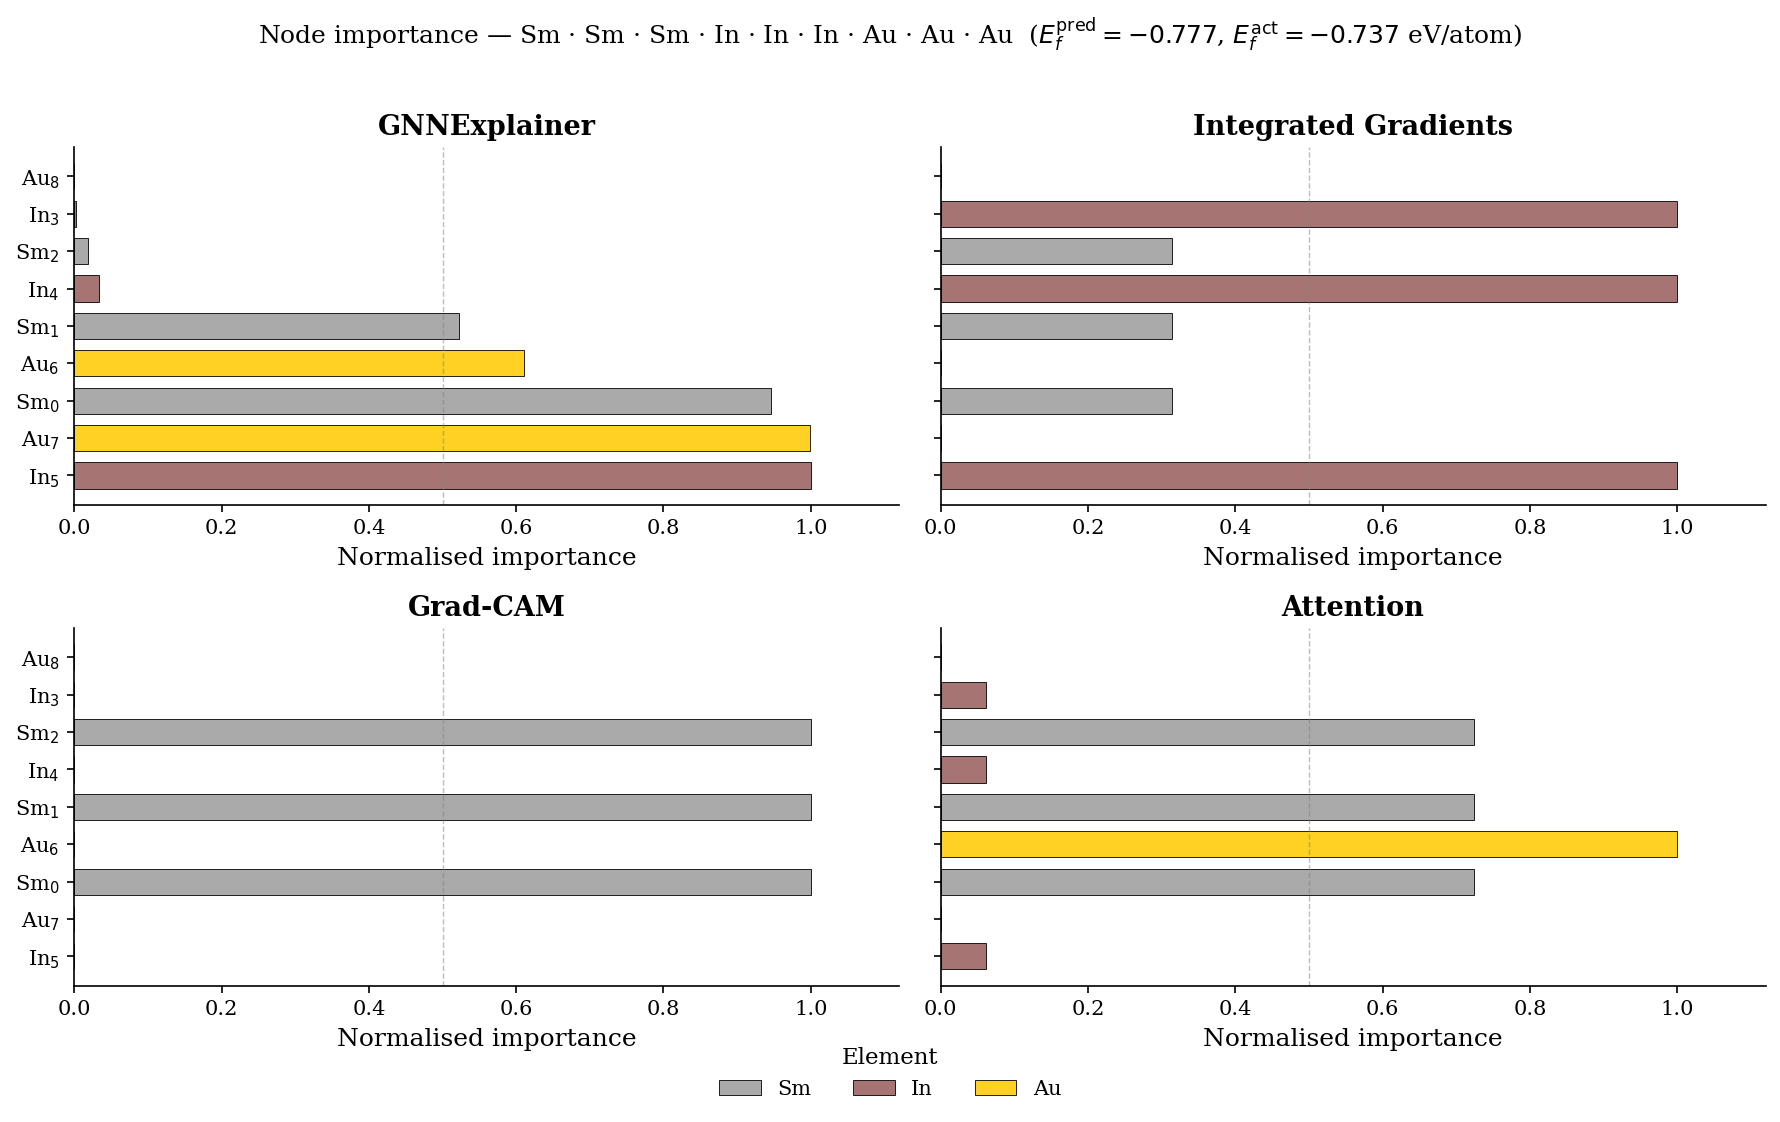

Saved fig1_node_importance_panel


In [ ]:
# ── Cell 11: Figure 1 — Per-atom importance panel (all 4 methods) ─────────
#
# A 2x2 grid of horizontal bar charts, one per method.
# Bars are coloured by element (CPK scheme); atoms are labelled with their
# element symbol.  This is the primary explainability figure for the paper.

methods     = ['GNNExplainer', 'Integrated Gradients', 'Grad-CAM', 'Attention']
scores_list = [gnn_node_imp, ig_node_imp, gradcam_node_imp, attn_node_imp]
colors_list = [PALETTE[i] for i in range(4)]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
axes = axes.flatten()

node_labels = [f'{sym}$_{{{i}}}$' for i, sym in enumerate(elem_syms)]
bar_colors  = [elem_color(sym) for sym in elem_syms]

for ax, method, scores, mc in zip(axes, methods, scores_list, colors_list):
    # Sort by importance descending for readability
    order = np.argsort(scores)[::-1]
    ax.barh(
        y     = [node_labels[i] for i in order],
        width = scores[order],
        color = [bar_colors[i] for i in order],
        edgecolor = 'k',
        linewidth = 0.4,
        height    = 0.7,
    )
    ax.set_xlim(0, 1.12)
    ax.set_xlabel('Normalised importance')
    ax.set_title(method, fontweight='bold')
    ax.axvline(0.5, color='grey', lw=0.7, linestyle='--', alpha=0.5)

# Shared legend: unique elements in this structure
unique_elems = list(dict.fromkeys(elem_syms))
patches = [Patch(facecolor=elem_color(e), edgecolor='k', linewidth=0.4, label=e)
           for e in unique_elems]
fig.legend(handles=patches, title='Element', loc='lower center',
           ncol=len(unique_elems), frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    f'Node importance — {" · ".join(elem_syms)}  '
    f'($E_f^{{\\mathrm{{pred}}}}={pred_val:.3f}$, $E_f^{{\\mathrm{{act}}}}={example.y.item():.3f}$ eV/atom)',
    y=1.01, fontsize=12,
)
plt.tight_layout()
plt.savefig('fig1_node_importance_panel.png')
plt.show()
print('Saved fig1_node_importance_panel')

Coordinate source: 3-D spring layout (no pos attribute found)


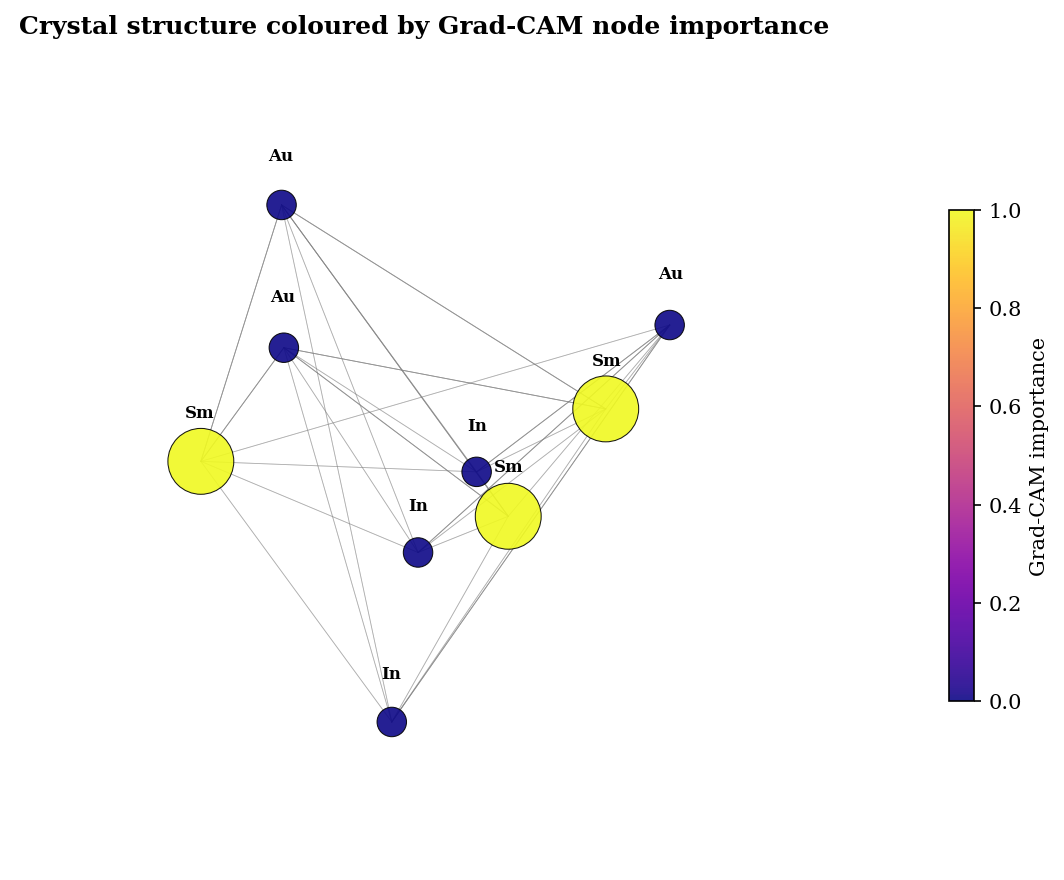

Saved fig2_crystal_structure_gradcam.pdf


In [ ]:
# ── Cell 12: Figure 2 — Crystal structure coloured by Grad-CAM ───────────
#
# Heusler structures are cubic; we approximate atom positions from the
# edge distances using a spring-layout embedding if 3-D coordinates are
# not stored in the graph.  If your graphs include a `pos` attribute from
# pymatgen (structure.cart_coords), those are used directly.

# Try to get 3-D coordinates
if hasattr(example, 'pos') and example.pos is not None:
    coords = example.pos.cpu().numpy()   # (N, 3)
    coord_source = '3-D Cartesian (from pos attribute)'
else:
    # Fall back: spring layout from edge distances → 3-D via PCA
    import networkx as nx
    from sklearn.decomposition import PCA
    G_nx = nx.Graph()
    G_nx.add_nodes_from(range(N))
    ei = example.edge_index.cpu().numpy()
    ea = example.edge_attr.cpu().numpy().flatten()
    for (s, d), dist in zip(ei.T, ea):
        if s < d:   # undirected, add once
            G_nx.add_edge(int(s), int(d), weight=float(dist))
    pos2d = nx.spring_layout(G_nx, seed=42, weight='weight')
    xy    = np.array([pos2d[i] for i in range(N)])
    # Add a Z-dimension via a simple embedding trick (use atomic Z / max_Z)
    z_coord = example.x[:, 0].cpu().numpy() / 100.0
    coords  = np.column_stack([xy, z_coord])
    coord_source = '3-D spring layout (no pos attribute found)'

print(f'Coordinate source: {coord_source}')

cmap    = plt.cm.plasma
sc_size = 200 + 800 * gradcam_node_imp   # larger sphere = higher importance

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    coords[:, 0], coords[:, 1], coords[:, 2],
    c     = gradcam_node_imp,
    s     = sc_size,
    cmap  = cmap,
    vmin  = 0, vmax = 1,
    edgecolors = 'k',
    linewidths = 0.5,
    depthshade = True,
    alpha = 0.9,
)

# Annotate each atom with element symbol
for i, (sym, xyz) in enumerate(zip(elem_syms, coords)):
    ax.text(xyz[0], xyz[1], xyz[2] + 0.04, sym,
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# Draw edges (thin, grey)
ei = example.edge_index.cpu().numpy()
for s, d in ei.T:
    xs = [coords[s, 0], coords[d, 0]]
    ys = [coords[s, 1], coords[d, 1]]
    zs = [coords[s, 2], coords[d, 2]]
    ax.plot(xs, ys, zs, color='grey', lw=0.4, alpha=0.4)

cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Grad-CAM importance', fontsize=10)
ax.set_title('Crystal structure coloured by Grad-CAM node importance',
             fontsize=12, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('fig2_crystal_structure_gradcam.pdf')
plt.show()
print('Saved fig2_crystal_structure_gradcam.pdf')

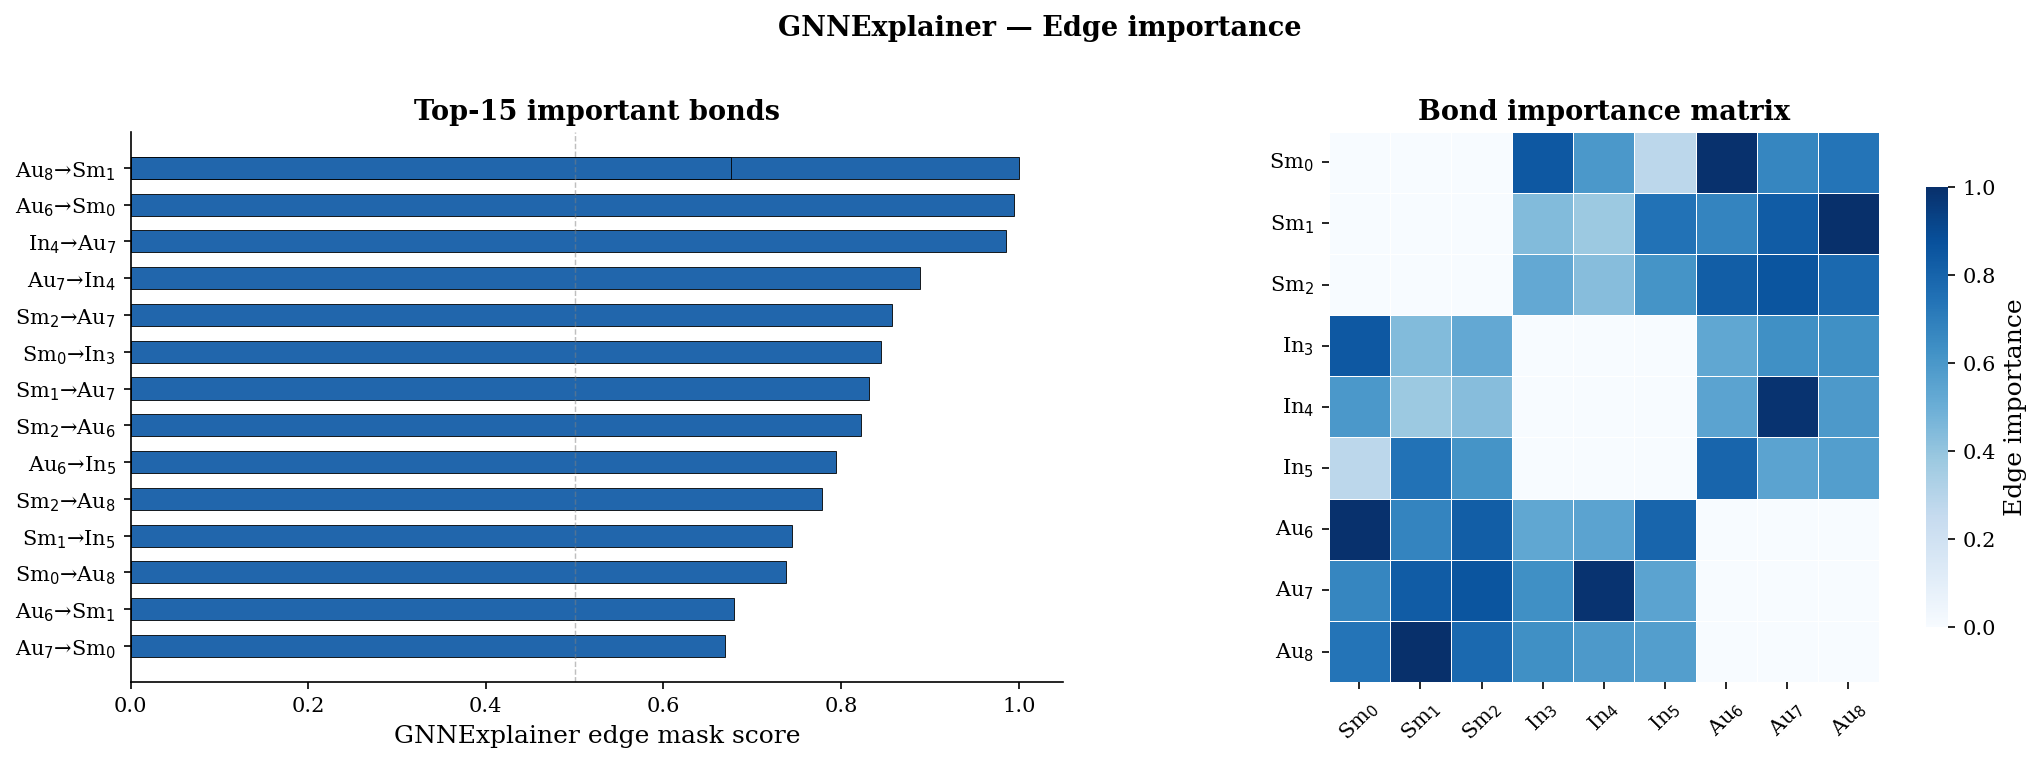

Saved fig3_edge_importance.pdf


In [ ]:
# ── Cell 13: Figure 3 — Edge importance from GNNExplainer ────────────────
#
# Two panels:
#   Left  — top-K directed edges ranked by GNNExplainer mask score.
#   Right — edge importance as an N×N heatmap (symmetric, undirected view).

K = min(15, gnn_edge_imp.size if hasattr(gnn_edge_imp,'size') else len(gnn_edge_imp))
ei_np   = example.edge_index.cpu().numpy()         # (2, E)
E       = ei_np.shape[1]

# Build N×N symmetric importance matrix
imp_matrix = np.zeros((N, N))
for idx in range(E):
    s, d = ei_np[0, idx], ei_np[1, idx]
    imp_matrix[s, d] = max(imp_matrix[s, d], gnn_edge_imp[idx])
    imp_matrix[d, s] = max(imp_matrix[d, s], gnn_edge_imp[idx])  # symmetrise

# Top-K edges
order_k   = np.argsort(gnn_edge_imp)[::-1][:K]
edge_labels = [f'{elem_syms[ei_np[0,i]]}$_{{{ei_np[0,i]}}}$→{elem_syms[ei_np[1,i]]}$_{{{ei_np[1,i]}}}$'
               for i in order_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: top-K bar chart
axes[0].barh(edge_labels, gnn_edge_imp[order_k],
             color=PALETTE[0], edgecolor='k', linewidth=0.4, height=0.6)
axes[0].set_xlabel('GNNExplainer edge mask score')
axes[0].set_title(f'Top-{K} important bonds', fontweight='bold')
axes[0].axvline(0.5, color='grey', lw=0.7, linestyle='--', alpha=0.5)
axes[0].invert_yaxis()

# Right: heatmap
tick_labels = [f'{sym}$_{{{i}}}$' for i, sym in enumerate(elem_syms)]
sns.heatmap(
    imp_matrix,
    ax          = axes[1],
    cmap        = 'Blues',
    vmin        = 0, vmax = 1,
    square      = True,
    linewidths  = 0.3,
    linecolor   = 'white',
    cbar_kws    = {'label': 'Edge importance', 'shrink': 0.8},
    xticklabels = tick_labels,
    yticklabels = tick_labels,
)
axes[1].set_title('Bond importance matrix', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('GNNExplainer — Edge importance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_edge_importance.pdf')
plt.show()
print('Saved fig3_edge_importance.pdf')

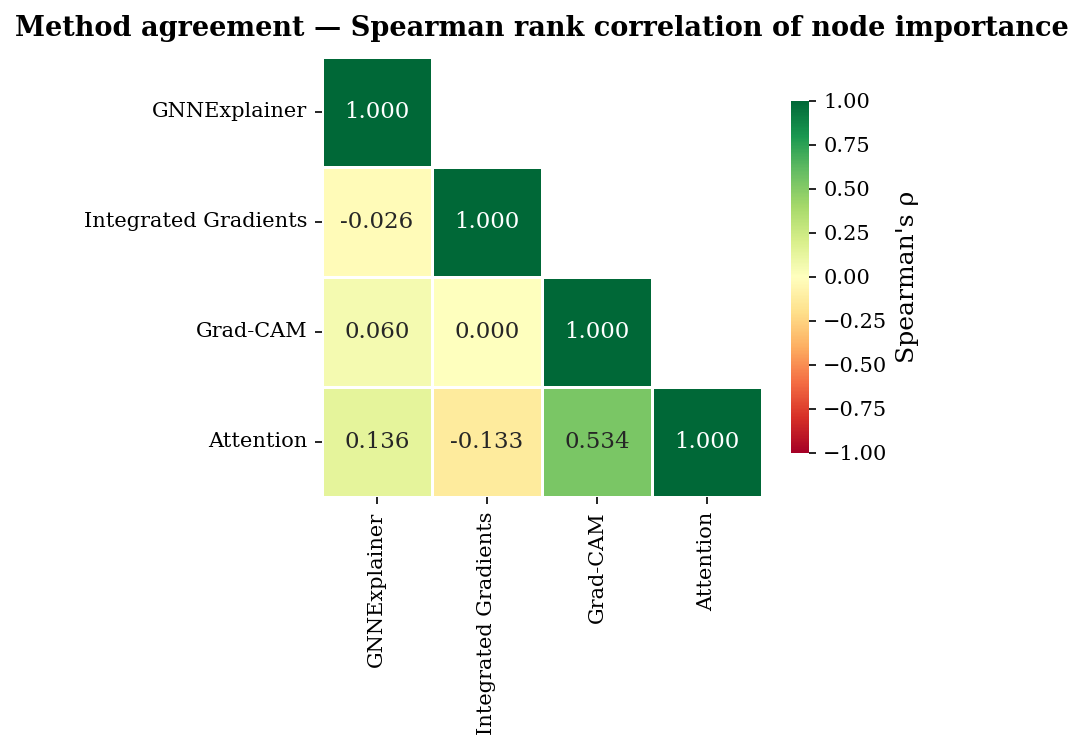

Saved fig4_method_agreement.pdf


In [ ]:
# ── Cell 14: Figure 4 — Method agreement matrix ───────────────────────────
#
# Spearman rank correlation between the four node importance rankings.
# High correlation → methods agree on which atoms matter.
# Low correlation → methods capture complementary signals.
# This plot directly supports a claim of method robustness in the paper.

all_scores = np.stack([
    gnn_node_imp, ig_node_imp, gradcam_node_imp, attn_node_imp
], axis=0)   # (4, N)

corr_matrix = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        if N > 2:
            rho, _ = spearmanr(all_scores[i], all_scores[j])
        else:
            rho = 1.0 if i == j else 0.0
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones((4, 4), dtype=bool), k=1)   # hide upper triangle

sns.heatmap(
    corr_matrix,
    ax          = ax,
    mask        = mask,
    annot       = True,
    fmt         = '.3f',
    cmap        = 'RdYlGn',
    vmin        = -1, vmax = 1,
    square      = True,
    linewidths  = 0.5,
    cbar_kws    = {'label': "Spearman's ρ", 'shrink': 0.8},
    xticklabels = methods,
    yticklabels = methods,
)
ax.set_title('Method agreement — Spearman rank correlation of node importance',
             fontweight='bold', pad=10)
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fig4_method_agreement.pdf')
plt.show()
print('Saved fig4_method_agreement.pdf')

Running Grad-CAM on 814 test structures...


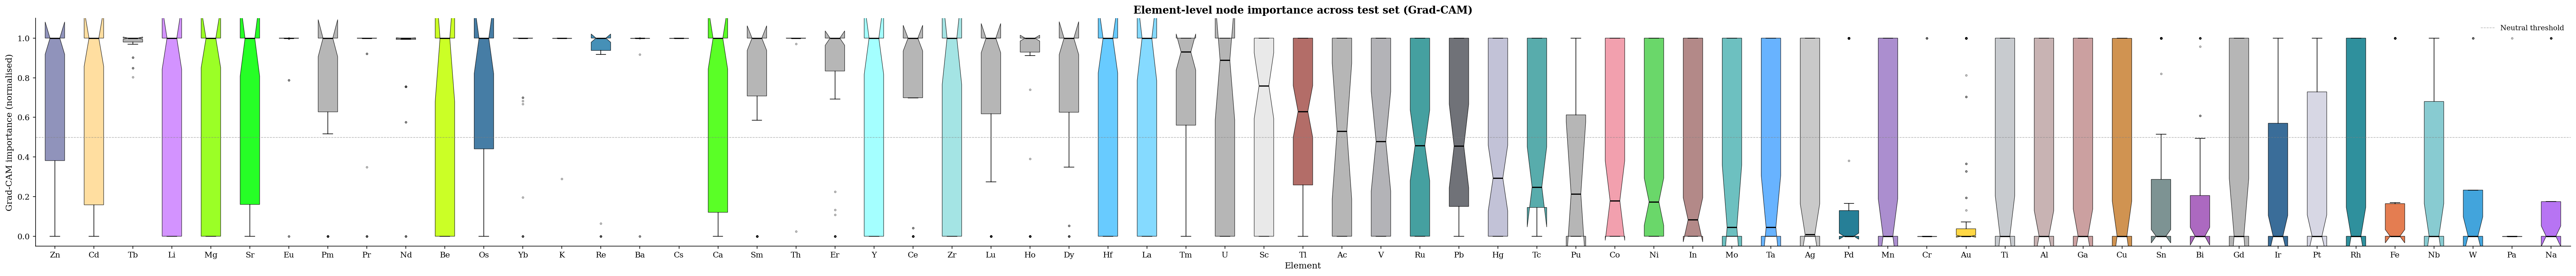

Saved fig5_element_importance.pdf


In [ ]:
# ── Cell 15: Figure 5 — Element-level importance over the test set ─────────
#
# The most publishable aggregated figure:
# Run Grad-CAM on every test graph, collect per-element importance scores,
# and plot as a box plot.  This answers the question:
# "Across all Heusler compounds in the test set, which sublattice elements
# contribute most to predicted formation energy?"
#
# We use Grad-CAM here for efficiency (no gradient tape re-runs needed
# beyond a single forward+backward pass per graph).

MAX_TEST = len(test_graphs)  # cap for runtime; remove cap for full run
elem_scores = defaultdict(list)         # element_symbol -> list of importance values

print(f'Running Grad-CAM on {MAX_TEST} test structures...')

for g in test_graphs[:MAX_TEST]:
    g = g.to(device)
    if not hasattr(g, 'batch') or g.batch is None:
        g.batch = torch.zeros(g.num_nodes, dtype=torch.long, device=device)

    _act_g, _grad_g = {}, {}
    hf = model.blocks[-1].norm.register_forward_hook(lambda m,i,o: _act_g.update({'v': o}))
    hb = model.blocks[-1].norm.register_full_backward_hook(lambda m,gi,go: _grad_g.update({'v': go[0]}))

    model.eval()
    out = model(g)
    model.zero_grad()
    out.sum().backward()

    hf.remove(); hb.remove()

    act   = _act_g['v'].detach()
    grad  = _grad_g['v'].detach()
    alpha = grad.mean(dim=-1, keepdim=True)
    cam   = F.relu((alpha * act).sum(dim=-1))
    imp   = norm01(cam.cpu().numpy())

    # Get element symbols for this graph
    zs = g.x[:, 0].long().cpu().numpy()
    try:
        from pymatgen.core import Element
        syms = [Element.from_Z(int(z)).symbol for z in zs]
    except Exception:
        syms = [f'Z{z}' for z in zs]

    for sym, val in zip(syms, imp):
        elem_scores[sym].append(float(val))

# Keep only elements with at least 5 observations
elem_scores = {k: v for k, v in elem_scores.items() if len(v) >= 5}
# Sort by median importance
elem_order  = sorted(elem_scores, key=lambda k: np.median(elem_scores[k]), reverse=True)

fig, ax = plt.subplots(figsize=(max(8, len(elem_order) * 0.7), 5))

box_data   = [elem_scores[e] for e in elem_order]
bp = ax.boxplot(
    box_data,
    patch_artist = True,
    notch        = True,
    medianprops  = dict(color='black', linewidth=1.5),
    whiskerprops = dict(linewidth=0.8),
    capprops     = dict(linewidth=0.8),
    flierprops   = dict(marker='o', markersize=2, alpha=0.4, linestyle='none'),
)
for patch, elem in zip(bp['boxes'], elem_order):
    patch.set_facecolor(elem_color(elem))
    patch.set_alpha(0.85)
    patch.set_edgecolor('k')
    patch.set_linewidth(0.6)

ax.set_xticks(range(1, len(elem_order) + 1))
ax.set_xticklabels(elem_order, fontsize=10)
ax.set_ylabel('Grad-CAM importance (normalised)', fontsize=11)
ax.set_xlabel('Element', fontsize=11)
ax.set_title('Element-level node importance across test set (Grad-CAM)',
             fontweight='bold', fontsize=13)
ax.axhline(0.5, color='grey', lw=0.7, linestyle='--', alpha=0.6, label='Neutral threshold')
ax.legend(fontsize=9, frameon=False)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig('fig5_element_importance.pdf')
plt.show()
print('Saved fig5_element_importance.pdf')

Found suitable structure at test index 1 with 3 unique points.


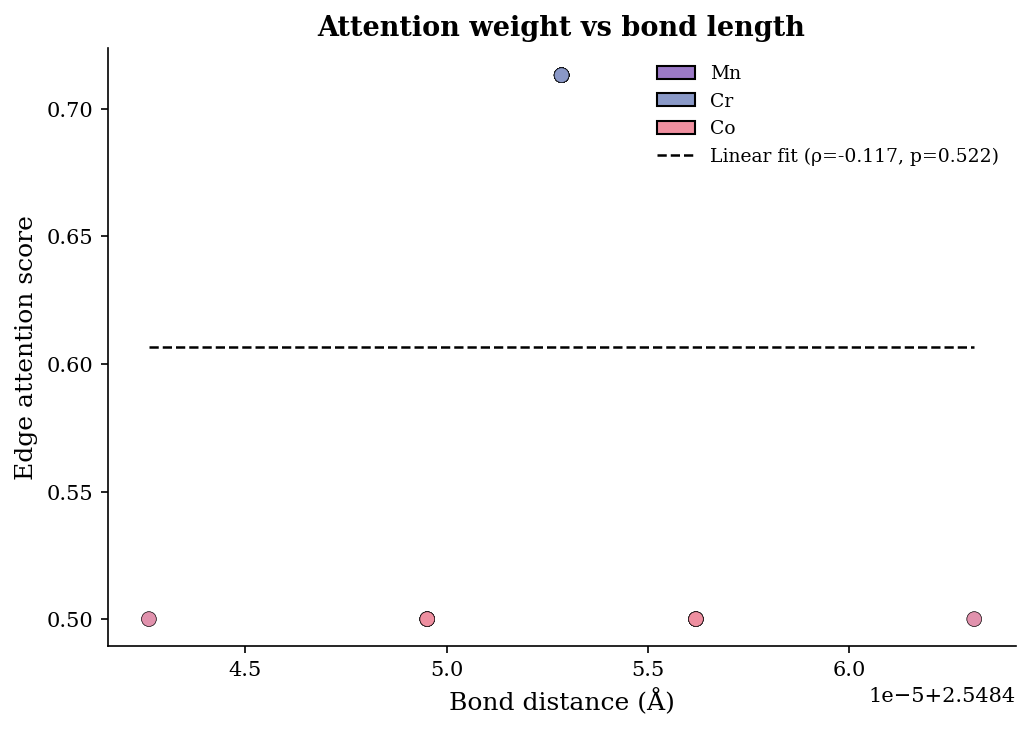

Saved fig6_attention_vs_distance.pdf (ρ=-0.12)


In [ ]:
# ── Cell 16: Figure 6 — Attention weight vs bond distance ━━━━━━━━━━━━━━━━
#
# Physics sanity check: find a structure with enough variance for correlation

found_valid = False
for search_idx in range(len(test_graphs)):
    test_ex = test_graphs[search_idx].to(device)
    if not hasattr(test_ex, 'batch') or test_ex.batch is None:
        test_ex.batch = torch.zeros(test_ex.num_nodes, dtype=torch.long, device=device)

    # Get attention for this graph
    _attn_tmp = []
    h_tmp = model.pool.gate_nn.register_forward_hook(lambda m, i, o: _attn_tmp.append(o.detach().cpu()))
    with torch.no_grad():
        _ = model(test_ex)
    h_tmp.remove()
    cur_attn = norm01(torch.sigmoid(_attn_tmp[0]).squeeze(-1).numpy())

    ei_tmp = test_ex.edge_index.cpu().numpy()
    di_tmp = test_ex.edge_attr.squeeze(-1).cpu().numpy()

    # Edge attention
    cur_edge_attn = np.array([(cur_attn[ei_tmp[0, k]] + cur_attn[ei_tmp[1, k]]) / 2 for k in range(ei_tmp.shape[1])])

    # Check uniqueness
    pts = set(zip(np.round(di_tmp, 4), np.round(cur_edge_attn, 4)))
    if len(pts) >= 3:
        print(f"Found suitable structure at test index {search_idx} with {len(pts)} unique points.")
        example = test_ex
        attn_node_imp = cur_attn
        dists = di_tmp
        edge_attn = cur_edge_attn
        found_valid = True
        break

if not found_valid:
    print("Warning: No structure with >2 unique points found. Using last checked.")

# Correlation
rho, pval = spearmanr(dists, edge_attn)
corr_label = f'ρ={rho:.3f}, p={pval:.3f}'

# Plotting
src_elems = []
try:
    from pymatgen.core import Element
    src_elems = [Element.from_Z(int(example.x[example.edge_index[0, k], 0].item())).symbol for k in range(dists.shape[0])]
except:
    src_elems = [f'Z{int(example.x[example.edge_index[0, k], 0].item())}' for k in range(dists.shape[0])]

src_colors = [elem_color(s) for s in src_elems]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(dists, edge_attn, c=src_colors, edgecolors='k', linewidths=0.3, s=50, alpha=0.75)

z = np.polyfit(dists, edge_attn, 1)
xfit = np.linspace(dists.min(), dists.max(), 200)
ax.plot(xfit, np.polyval(z, xfit), 'k--', lw=1.2, label=f'Linear fit ({corr_label})')

ax.set_xlabel('Bond distance (Å)')
ax.set_ylabel('Edge attention score')
ax.set_title('Attention weight vs bond length', fontweight='bold')

unique_src = list(dict.fromkeys(src_elems))
patches = [Patch(facecolor=elem_color(e), edgecolor='k', label=e) for e in unique_src]
ax.legend(handles=patches + ax.get_lines(), fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('fig6_attention_vs_distance.pdf')
plt.show()
print(f'Saved fig6_attention_vs_distance.pdf (ρ={rho:.2f})')

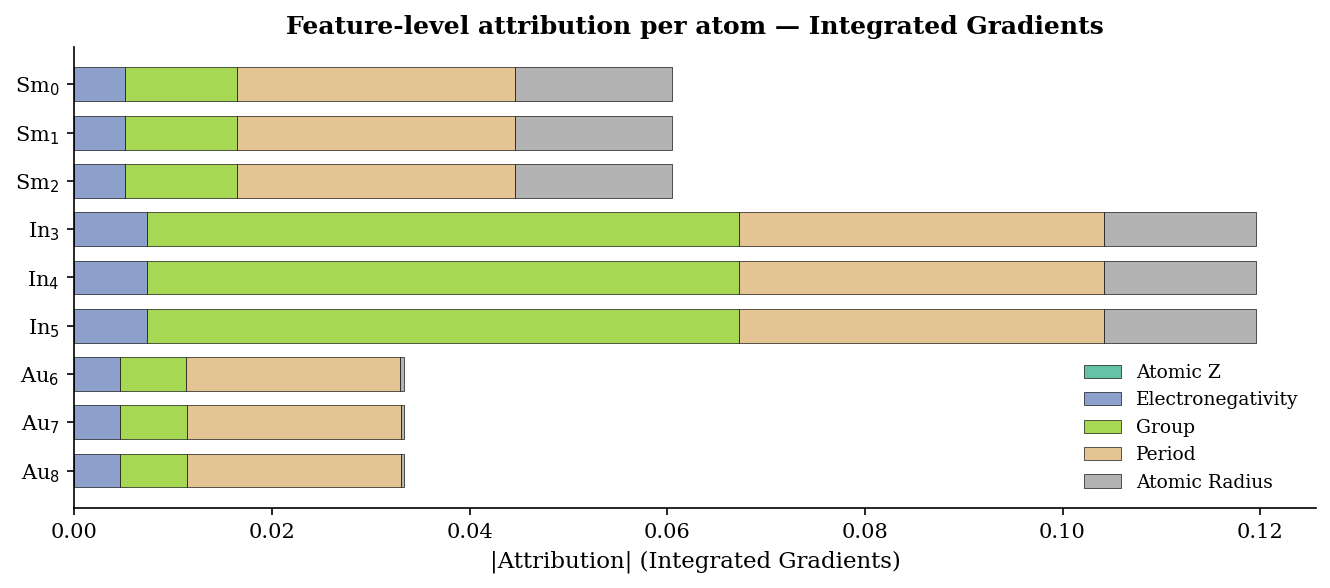

Saved fig1b_ig_feature_attribution.pdf


In [ ]:
# ── Cell 17: Figure 1b — Integrated Gradients feature attribution ─────────
#
# Complements Fig 1 with a feature-level view:
# Which of the 5 atomic descriptor dimensions drives each atom's attribution?
# Presented as a stacked horizontal bar chart — useful for the methods section.

feat_attr_per_node = attributions.squeeze(0).abs().detach().cpu().numpy()  # (N, 5)

fig, ax = plt.subplots(figsize=(9, max(4, N * 0.45)))

feat_colors = plt.cm.Set2(np.linspace(0, 1, len(feature_names)))
bottoms     = np.zeros(N)
node_idx    = np.arange(N)

for fi, (fname, fc) in enumerate(zip(feature_names, feat_colors)):
    vals = feat_attr_per_node[:, fi]
    ax.barh(node_idx, vals, left=bottoms, height=0.7,
            color=fc, edgecolor='k', linewidth=0.3, label=fname)
    bottoms += vals

ax.set_yticks(node_idx)
ax.set_yticklabels(node_labels, fontsize=10)
ax.set_xlabel('|Attribution| (Integrated Gradients)', fontsize=11)
ax.set_title('Feature-level attribution per atom — Integrated Gradients',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=9, frameon=False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('fig1b_ig_feature_attribution.pdf')
plt.show()
print('Saved fig1b_ig_feature_attribution.pdf')

In [ ]:
# ── Cell 18: Summary table ─────────────────────────────────────────────────
#
# Print a LaTeX-ready table of per-atom importance scores from all methods.
# Copy directly into the supplementary material.

# Restore 'example' to the one selected in Cell 5 (or custom selection)
# as it might have been overwritten by Cell 16 for Fig 6.
if 'EXAMPLE_IDX' in globals() and 'test_graphs' in globals():
    example = test_graphs[EXAMPLE_IDX].to(device)
    if not hasattr(example, 'batch') or example.batch is None:
        example.batch = torch.zeros(example.num_nodes, dtype=torch.long, device=device)

    # Re-calculate attn_node_imp for this example
    _attn_raw = []
    def _attn_hook(module, inp, out):
        _attn_raw.append(out.detach().cpu())
    h_attn = model.pool.gate_nn.register_forward_hook(_attn_hook)
    with torch.no_grad():
        _ = model(example)
    h_attn.remove()
    attn_node_imp = norm01(torch.sigmoid(_attn_raw[0]).squeeze(-1).numpy())

    # Re-generate elem_syms and node_labels if example changed
    N = example.num_nodes
    elem_syms = []
    try:
        from pymatgen.core import Element
        elem_syms = [Element.from_Z(int(example.x[i, 0].item())).symbol for i in range(N)]
    except Exception:
        elem_syms = [f'Z{int(example.x[i,0].item())}' for i in range(N)]
    node_labels = [f'{sym}$_{{{i}}}$' for i, sym in enumerate(elem_syms)]


df_out = pd.DataFrame({
    'Atom'              : node_labels,
    'Element'           : elem_syms,
    'GNNExplainer'      : gnn_node_imp.round(4),
    'Integ. Gradients'  : ig_node_imp.round(4),
    'Grad-CAM'          : gradcam_node_imp.round(4),
    'Attention'         : attn_node_imp.round(4),
})

print('=== Node importance table ===')
print(df_out.to_string(index=False))
print()
print('=== LaTeX snippet ===')
print(df_out.to_latex(index=False, float_format='%.4f',
                      caption='Node importance scores from four XAI methods.',
                      label='tab:xai_importance'))

=== Node importance table ===
    Atom Element  GNNExplainer  Integ. Gradients  Grad-CAM  Attention
Sm$_{0}$      Sm        0.9456            0.3142       1.0     0.7242
Sm$_{1}$      Sm        0.5224            0.3142       1.0     0.7242
Sm$_{2}$      Sm        0.0181            0.3142       1.0     0.7242
In$_{3}$      In        0.0029            1.0000       0.0     0.0612
In$_{4}$      In        0.0332            1.0000       0.0     0.0612
In$_{5}$      In        1.0000            1.0000       0.0     0.0612
Au$_{6}$      Au        0.6101            0.0000       0.0     1.0000
Au$_{7}$      Au        0.9995            0.0003       0.0     0.0000
Au$_{8}$      Au        0.0000            0.0003       0.0     0.0000

=== LaTeX snippet ===
\begin{table}
\caption{Node importance scores from four XAI methods.}
\label{tab:xai_importance}
\begin{tabular}{llrrrr}
\toprule
Atom & Element & GNNExplainer & Integ. Gradients & Grad-CAM & Attention \\
\midrule
Sm$_{0}$ & Sm & 0.9456 & 0.3142 &

In [ ]:
# ── Cell 19: All saved figures ────────────────────────────────────────────
import os
pdfs = sorted([f for f in os.listdir('.') if f.endswith('.pdf')])
print('Generated figures:')
for f in pdfs:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:<45}  {size_kb:.1f} KB')